
--- Madrid ---
Total number of days  334 

state     n_x       n_x/N     
----------------------------------------
0         52        0.15568862275449102
1         50        0.1497005988023952
2         44        0.1317365269461078
3         26        0.07784431137724551
4         44        0.1317365269461078
5         39        0.11676646706586827
6         33        0.09880239520958084
7         35        0.10479041916167664
8         11        0.03293413173652695

--- Prague ---
Total number of days  334 

state     n_x       n_x/N     
----------------------------------------
0         16        0.04790419161676647
1         15        0.04491017964071856
2         17        0.05089820359281437
3         32        0.09580838323353294
4         22        0.0658682634730539
5         38        0.11377245508982035
6         65        0.19461077844311378
7         92        0.2754491017964072
8         37        0.11077844311377245

--- Hamburg ---
Total number of days  334 

state   

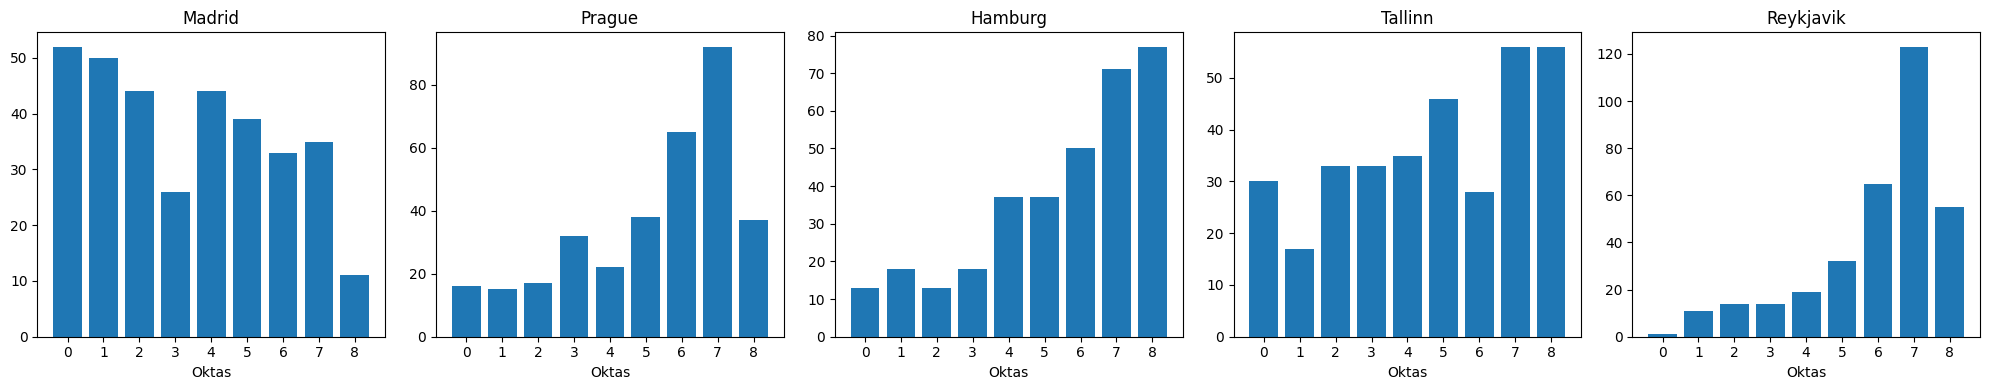

In [ ]:
#Importing Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import scipy.stats as stats
from collections import Counter
import openpyxl
import seaborn as sns
# Loads daily cloud cover data for each city from Excel files.
# Splits data into:
# Training set : Jan 1 - Nov 30, 2025 (used to fit the model)
# Test set 1   : December 2025        (for December predictions)
# Test set 2   : January 2026         (for January predictions)
# Computes observed frequencies of each cloud cover state (0-8 oktas)
# and plots bar charts for visual inspection.
def frequencies(s):
    state = '012345678'
    N = len(s)
    freq = []
    freq_N = []
    for x in state:
        n = (s == int(x)).sum()
        freq.append(n)
        freq_N.append(n / N)
    return freq, freq_N

def load_and_compute(path,city_name,ax):
    df = pd.read_excel(path)
    df.columns = df.columns.str.strip()
    df['DATE'] = pd.to_datetime(df['DATE'].astype(int).astype(str), format='%Y%m%d')

    train_df = df[df['DATE'].dt.year == 2025]
    train_df = train_df[train_df['DATE'].dt.month <= 11]

    test1_df = df[(df['DATE'].dt.year == 2025) & (df['DATE'].dt.month == 12)]
    test2_df = df[(df['DATE'].dt.year == 2026) & (df['DATE'].dt.month == 1)]
    test = pd.concat([test1_df, test2_df], ignore_index=True)
    freq_d, freq_d_N = frequencies(train_df['CC'])

    print(f"\n--- {city_name} ---")
    print("Total number of days ", len(train_df), '\n')
    print(f"{'state':<10}{'n_x':<10}{'n_x/N':<10}")
    print("-" * 40)
    for k in range(9):
        print(f"{k:<10}{freq_d[k]:<10}{freq_d_N[k]:<10}")
    
        
   
    ax.bar(range(9), freq_d)
    ax.set_title(city_name)
    ax.set_xlabel('Oktas')
    ax.set_xticks(range(9))

    return freq_d, freq_d_N, train_df, df, test, test1_df, test2_df


fig, axes = plt.subplots(1, 5, figsize=(20, 4))

freq_d_madrid,    freq_d_N_madrid, train_madrid, df_madrid, test_madrid,test1_madrid, test2_madrid    = load_and_compute('C:/Users/comp/Desktop/qaxaqner/madrid.xlsx',    'Madrid',    axes[0])
freq_d_prague,     freq_d_N_prague, train_prague, df_prague, test_prague, test1_prague, test2_prague    = load_and_compute('C:/Users/comp/Desktop/qaxaqner/prague.xlsx',     'Prague',     axes[1])
freq_d_hamburg,   freq_d_N_hamburg, train_hamburg, df_hamburg, test_hamburg, test1_hamburg, test2_hamburg  = load_and_compute('C:/Users/comp/Desktop/qaxaqner/hamburg.xlsx',   'Hamburg',   axes[2])
freq_d_tallinn,   freq_d_N_tallinn, train_tallinn, df_tallinn, test_tallinn, test1_tallinn, test2_tallinn = load_and_compute('C:/Users/comp/Desktop/qaxaqner/tallinn.xlsx',   'Tallinn',   axes[3])
freq_d_reykjavik, freq_d_N_reykjavik, train_reykjavik, df_reykjavik, test_reykjavik, test1_reykjavik, test2_reykjavik = load_and_compute('C:/Users/comp/Desktop/qaxaqner/reykjavik.xlsx', 'Reykjavik', axes[4])


plt.tight_layout()
plt.show()

In [ ]:
 # Pearson chi square test
# obesrved values are from freq_t, expected values are N*freq_d_N
# Test whether daily cloud cover observations are independent of each other.
# This is the Pearson chi-square goodness-of-fit test (Section 3.2 of the thesis).
# for Dec 2025 and Jan 2026
import scipy.stats as stats
from collections import Counter
def chi_square_test(freq_d_N, test_df, city_name):
    freq_t = [0]*9
    freq_t_N = [0]*9
    freq_t, freq_t_N = frequencies(test_df['CC'])


    freq_exp = [[0] * 9 for _ in range(9)]

    for i in range(9):
        freq_exp[i] = int(freq_d_N[i]*len(test_df))

    print(f"{'state':<10}{'exp':<10}{'obs':<10}")
    for i in range(9):
        print(f"{i:<10}{freq_exp[i]:<10}{freq_t[i]:<10}")

    # define the chi square statistic

    chi = 0
    for i in range(9):
        if freq_exp[i] != 0:
            chi = chi + (freq_t[i] - freq_exp[i])**2 / freq_exp[i]

    # define critical value for 9-1=8 degrees of freedom and significance alpha

    alpha = 0.05
    chi_cr = stats.chi2.ppf(1-alpha, 8)

    print(chi, chi_cr)

    # test
    if chi > chi_cr:
        print(f"{city_name}: reject H0, states in Dec and Jan are not distributed as freq_d_N")
    else:
        print(f"{city_name}: H0 can be accepted, states in Dec and Jan are distributed as freq_d_N")

chi_square_test(freq_d_N_madrid, test_madrid,   'Madrid')
chi_square_test(freq_d_N_prague, test_prague,   'Prague')
chi_square_test(freq_d_N_hamburg, test_hamburg,   'Hamburg')
chi_square_test(freq_d_N_tallinn, test_tallinn,   'Tallinn')
chi_square_test(freq_d_N_reykjavik, test_reykjavik,   'Reykjavik')


state     exp       obs       
0         9         3         
1         9         5         
2         8         3         
3         4         2         
4         8         13        
5         7         13        
6         6         6         
7         6         11        
8         2         6         
30.33730158730159 15.507313055865453
Madrid: reject H0, states in Dec and Jan are not distributed as freq_d_N
state     exp       obs       
0         2         3         
1         2         2         
2         3         4         
3         5         2         
4         4         2         
5         7         7         
6         12        4         
7         17        13        
8         6         25        
70.07450980392157 15.507313055865453
Prague: reject H0, states in Dec and Jan are not distributed as freq_d_N
state     exp       obs       
0         2         3         
1         3         1         
2         2         1         
3         3         1         
4    

In [ ]:
# function to count frequencies of pairs of states

def pairs_frequencies (s):
    pair_counts = [[0 for col in range(9)] for row in range(9)]
    for k in range(len(s) - 1):
        i = int(s.iloc[k])
        j = int(s.iloc[k+1])
        
        if i > 8 or j > 8 or i < 0 or j < 0:
            print(f"Invalid value at k={k}: i={i}, j={j}")
            continue
        pair_counts[i][j] += 1
    return pair_counts

# count pairs' frequencies for data
def transition_matrix(freq_d,train_df, city_name):
    matrix_d = [[0] * 9 for _ in range(9)]

    matrix_d = pairs_frequencies(train_df['CC'])

    # print frequencies
    print(f"\n--- {city_name} transition matrix ---")

    for i in range(9):
        for j in range(9):
            print(matrix_d[i][j], end=" ")
        print("\n")

    # define transition probabilities matrix

    P_data = [[0] * 9 for _ in range(9)]
    print(f"\n--- {city_name} P matrix ---")
    for i in range(9):
        for j in range(9):
             if freq_d[i] != 0:
                P_data[i][j] = matrix_d[i][j]/freq_d[i]
        for j in range(9):
                print(round(P_data[i][j], 3), end=" ")
        print()
    return P_data
P_madrid    = transition_matrix(freq_d_madrid,    train_madrid,    'Madrid')
P_prague     = transition_matrix(freq_d_prague,     train_prague,     'Prague')
P_hamburg   = transition_matrix(freq_d_hamburg,   train_hamburg,   'Hamburg')
P_tallinn   = transition_matrix(freq_d_tallinn,   train_tallinn,   'Tallinn')
P_reykjavik = transition_matrix(freq_d_reykjavik, train_reykjavik, 'Reykjavik')


--- Madrid transition matrix ---
17 14 7 4 6 2 0 2 0 

12 6 8 3 6 8 4 3 0 

12 10 10 4 4 1 2 0 1 

2 3 3 3 2 5 4 2 2 

5 8 8 2 5 6 4 4 2 

1 4 3 5 7 7 3 8 0 

2 2 0 2 7 7 5 6 2 

1 2 4 3 7 2 7 8 1 

0 0 1 0 0 1 4 2 3 


--- Madrid P matrix ---
0.327 0.269 0.135 0.077 0.115 0.038 0.0 0.038 0.0 
0.24 0.12 0.16 0.06 0.12 0.16 0.08 0.06 0.0 
0.273 0.227 0.227 0.091 0.091 0.023 0.045 0.0 0.023 
0.077 0.115 0.115 0.115 0.077 0.192 0.154 0.077 0.077 
0.114 0.182 0.182 0.045 0.114 0.136 0.091 0.091 0.045 
0.026 0.103 0.077 0.128 0.179 0.179 0.077 0.205 0.0 
0.061 0.061 0.0 0.061 0.212 0.212 0.152 0.182 0.061 
0.029 0.057 0.114 0.086 0.2 0.057 0.2 0.229 0.029 
0.0 0.0 0.091 0.0 0.0 0.091 0.364 0.182 0.273 

--- Prague transition matrix ---
8 1 1 2 1 1 2 0 0 

5 1 3 3 3 0 0 0 0 

0 2 3 2 1 2 2 5 0 

0 5 0 5 2 4 6 5 5 

1 1 2 2 3 3 3 6 1 

2 0 4 6 2 5 6 11 2 

0 4 0 4 2 10 14 23 8 

0 1 3 8 5 9 26 31 9 

0 0 1 0 3 4 6 10 12 


--- Prague P matrix ---
0.5 0.062 0.062 0.125 0.062 0.062 0.125 0.0 0

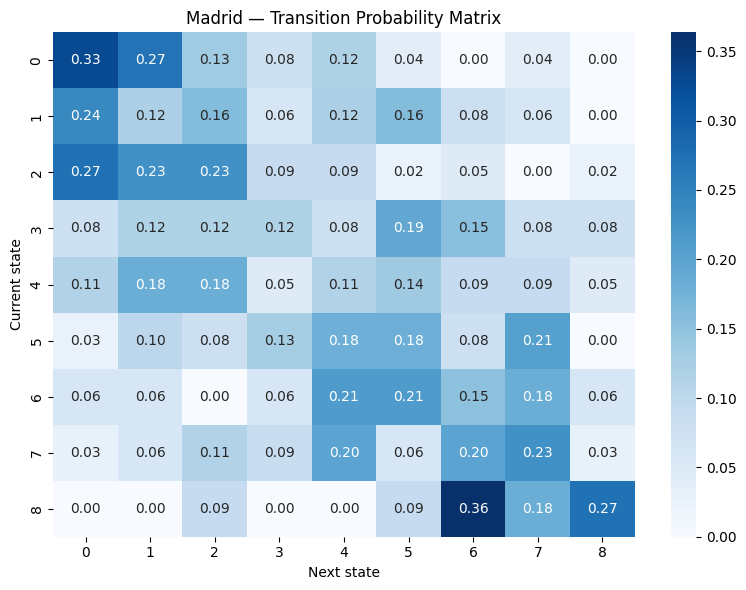

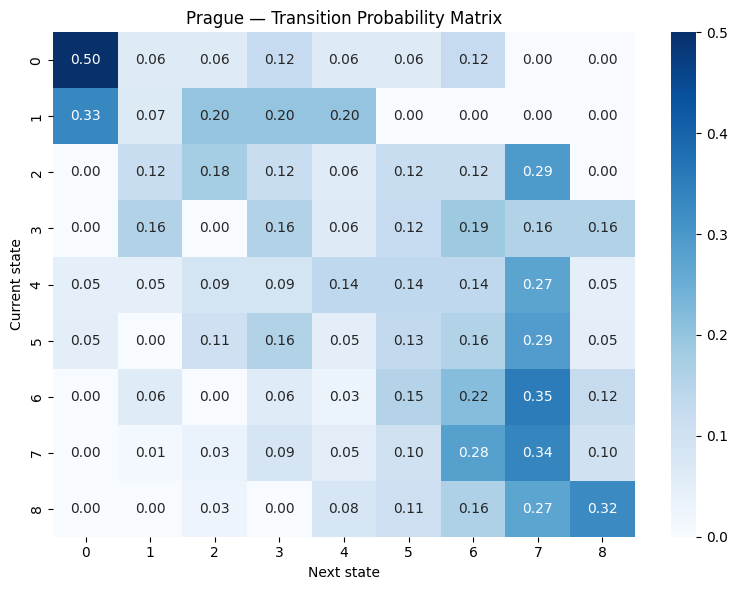

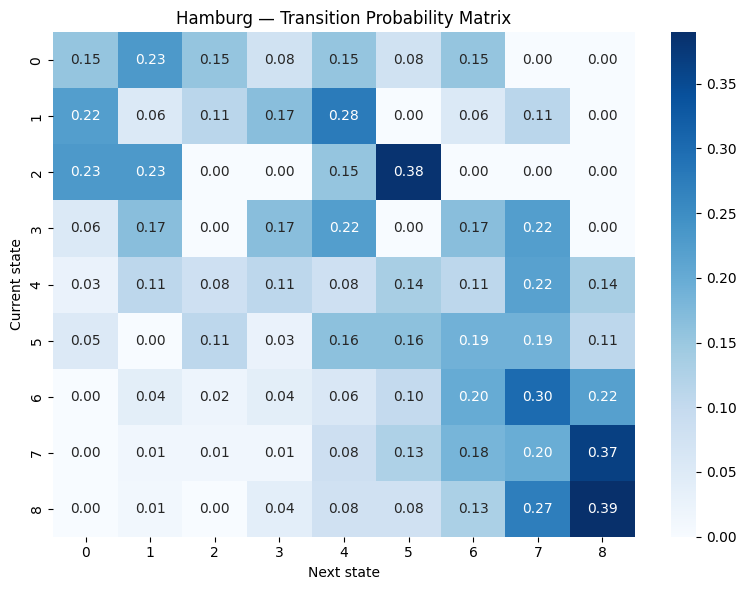

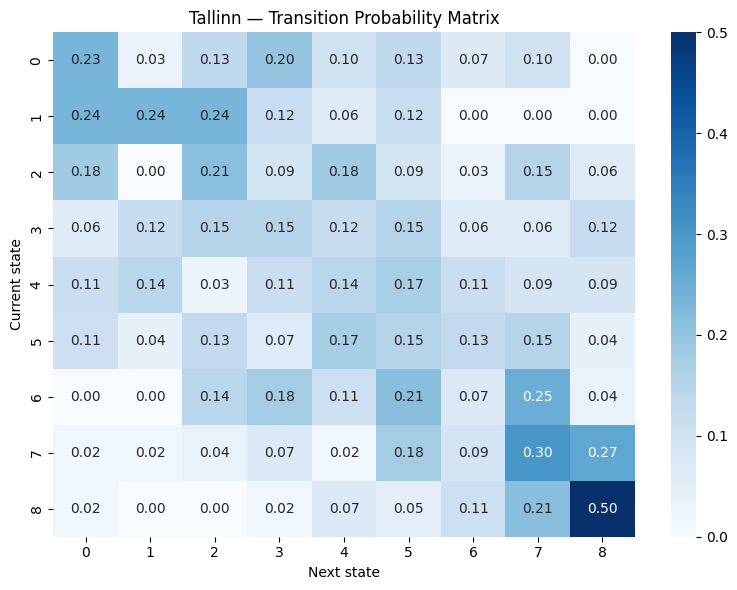

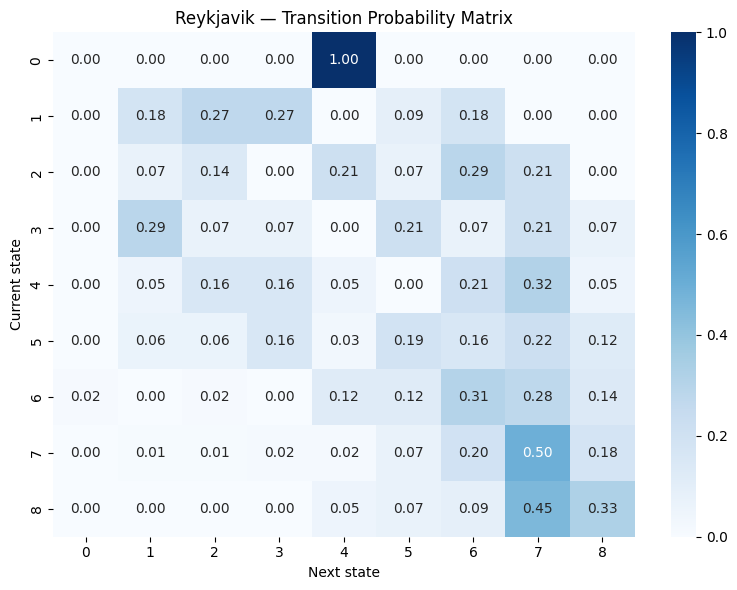

In [ ]:
#VISUALIZE TRANSITION MATRICES AS HEATMAPS
cities = [('Madrid', P_madrid), ('Prague', P_prague), 
          ('Hamburg', P_hamburg), ('Tallinn', P_tallinn), 
          ('Reykjavik', P_reykjavik)]

for city, P in cities:
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(P, ax=ax, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=range(9), yticklabels=range(9))
    ax.set_title(f'{city} — Transition Probability Matrix')
    ax.set_xlabel('Next state')
    ax.set_ylabel('Current state')
    plt.tight_layout()
    plt.savefig(f'{city}_heatmap.png', dpi=300)
    plt.show()

In [21]:
# predict weather in December in Markov chain model
import numpy as np
# set initial distribution p0
def weather_dec(test1_df, P, city_name ):
    p0 = [0]*9
    i = int(test1_df['CC'].iloc[0])
    p0[i] = 1

    print(f"\n--- {city_name} ---")
    print("Weather on December 1, 2025", i)

    # transition probability matrix P = P_data
    # p0*P, p0*P^2,..., p0*P^31 - distributions for states in December 2025

    P_dec = [[0] * 9 for _ in range(9)]

    predict_dec = []
    cur_st = p0
    for n in range(31):
        next_st = np.dot(cur_st, P)
        predict_dec.append(str(np.argmax(next_st)))
        cur_st = next_st

   
    print("predicted weather:")
    print(''.join(predict_dec))
    print("observed weather:")
    print(''.join(test1_df['CC'].astype(str).tolist()))
    
    # exact coincides

    correct = 0

    for i in range(31):
        if predict_dec[i] == str(test1_df['CC'].iloc[i]):
            correct += 1
    print("correct prediction:", round((correct/31)*100, 2), "%")

    # + - one state

    correct_1 = 0

    for i in range(31):
        if (int(predict_dec[i]) == int(test1_df['CC'].iloc[i]) or 
            int(predict_dec[i]) - 1 == int(test1_df['CC'].iloc[i]) or 
            int(predict_dec[i]) + 1 == int(test1_df['CC'].iloc[i])):
            correct_1 += 1
  
    print("if we include closest states, the correct prediction is done in", round((correct_1/31)*100, 2), "% of cases")
weather_dec(test1_madrid,    P_madrid,    'Madrid')
weather_dec(test1_prague,     P_prague,     'Prague')
weather_dec(test1_hamburg,   P_hamburg,   'Hamburg')
weather_dec(test1_tallinn,   P_tallinn,   'Tallinn')
weather_dec(test1_reykjavik, P_reykjavik, 'Reykjavik')


--- Madrid ---
Weather on December 1, 2025 4
predicted weather:
1000000000000000000000000000000
observed weather:
4547567568155775247446735546400
correct prediction: 6.45 %
if we include closest states, the correct prediction is done in 9.68 % of cases

--- Prague ---
Weather on December 1, 2025 7
predicted weather:
7777777777777777777777777777777
observed weather:
7888787775368888788888851221546
correct prediction: 19.35 %
if we include closest states, the correct prediction is done in 70.97 % of cases

--- Hamburg ---
Weather on December 1, 2025 5
predicted weather:
6788888888888888888888888888888
observed weather:
5888888788877724778788430654717
correct prediction: 35.48 %
if we include closest states, the correct prediction is done in 70.97 % of cases

--- Tallinn ---
Weather on December 1, 2025 7
predicted weather:
7888877777777777777777777777777
observed weather:
7588888888847888868878777365782
correct prediction: 32.26 %
if we include closest states, the correct prediction is d

In [22]:
def predict_january(test2_df, p_lim, city_name):
    states = list(range(9))
    
    # generate 31 values by limiting distribution
    expected = np.random.choice(states, size=31, p=p_lim)
    
    print(f"\n--- {city_name} ---")
    print("predicted weather:")
    print(''.join(map(str, expected)))
    print("observed weather:")
    print(''.join(test2_df['CC'].astype(str).tolist()))
    
    correct = sum(expected[i] == int(test2_df['CC'].iloc[i]) for i in range(31))
    print("correct prediction:", round((correct/31)*100, 2), "%")
    
    correct_1 = sum(
        abs(int(expected[i]) - int(test2_df['CC'].iloc[i])) <= 1 
        for i in range(31)
    )
    print("correct prediction +-1:", round((correct_1/31)*100, 2), "%")

In [23]:
# function to find approximations for limiting distributions
# p - initial distribution, P - transition probabilities matrix
# n - number of iterations to count P^n, tol = tolerance, number of digits after 0.

def P_inf (p, P, n, tol, city_name):
    print(f"\n---{city_name}---")
    print(f"{'Iteration':<20}{'0':<10}{'1':<10}{'2':<10}{'3':<10}{'4':<10}{'5':<10}{'6':<10}{'7':<10}{'8':<10}")
    print("-" * 50)

    #p0 = [1/9] * 9
    cur_st = p
    for i in range(1, n + 1):
        next_st = np.dot(cur_st, P)
        print(f"{i:<20}{next_st[0]:<10.5f}{next_st[1]:<10.5f}{next_st[2]:<10.5f}{next_st[3]:<10.5f}{next_st[4]:<10.5f}{next_st[5]:<10.5f}{next_st[6]:<10.5f}{next_st[7]:<10.5f}{next_st[8]:<10.5f}")
        if np.allclose(cur_st, next_st, atol = tol):
            print("\n Convergence achieved on iteration", i) # rows in P^n do not change any more
            return(next_st)
        cur_st = next_st
    return cur_st
# find limiting distribution with an accuracy of up to 4 decimal places

def make_p0(test1_df):
    p0 = [0] * 9
    i = int(test1_df['CC'].iloc[0])  # դեկտ. 1-ի ամպամածությունը
    p0[i] = 1
    return p0

p0_madrid    = make_p0(test1_madrid)
p0_prague     = make_p0(test1_prague)
p0_hamburg   = make_p0(test1_hamburg)
p0_tallinn   = make_p0(test1_tallinn)
p0_reykjavik = make_p0(test1_reykjavik)

p_lim_madrid    = P_inf(p0_madrid,    P_madrid,    100, 1e-3, 'Madrid')
p_lim_prague     = P_inf(p0_prague,     P_prague,     100, 1e-3, 'Prague')
p_lim_hamburg   = P_inf(p0_hamburg,   P_hamburg,   100, 1e-3, 'Hamburg')
p_lim_tallinn   = P_inf(p0_tallinn,   P_tallinn,   100, 1e-3, 'Tallinn')
p_lim_reykjavik = P_inf(p0_reykjavik, P_reykjavik, 100, 1e-3, 'Reykjavik')


---Madrid---
Iteration           0         1         2         3         4         5         6         7         8         
--------------------------------------------------
1                   0.11364   0.18182   0.18182   0.04545   0.11364   0.13636   0.09091   0.09091   0.04545   
2                   0.15839   0.14433   0.13663   0.07737   0.12981   0.11492   0.09911   0.10265   0.03330   
3                   0.15627   0.14720   0.13159   0.07763   0.13090   0.11541   0.09796   0.10361   0.03298   
4                   0.15501   0.14610   0.13097   0.07734   0.13072   0.11574   0.09804   0.10388   0.03280   
5                   0.15414   0.14547   0.13046   0.07715   0.13047   0.11550   0.09788   0.10384   0.03272   

 Convergence achieved on iteration 5

---Prague---
Iteration           0         1         2         3         4         5         6         7         8         
--------------------------------------------------
1                   0.00000   0.01087   0.03261   0.086

In [26]:
# we can predict weather in January by the limiting distribution
# find the most probable state and compare with states in January
def transition_matrix_month(df, months):
    df = df[df['CC'].between(0, 8)]
    month_df = df[df['DATE'].dt.month.isin(months)]
    freq_d, _ = frequencies(month_df['CC'])
    matrix_d = pairs_frequencies(month_df['CC'])
    
    P = [[0] * 9 for _ in range(9)]
    for i in range(9):
        for j in range(9):
            if freq_d[i] != 0:
                P[i][j] = matrix_d[i][j] / freq_d[i]
    return P

def predict_january(test2_df, p_lim, city_name):
    most_probable = np.argmax(p_lim)
    
    predict_jan = [str(most_probable)] * len(test2_df)  # բոլոր 31 օրերը

    print(f"\n--- {city_name} ---")
    print("predicted weather in January:")
    print(''.join(predict_jan))
    print("observed weather:")
    print(''.join(test2_df['CC'].astype(str).tolist()))

    correct = test2_df['CC'].isin([most_probable]).sum()
    print("the correct prediction is done in", round((correct/len(test2_df))*100, 2), "% of cases")

    correct_1 = test2_df['CC'].isin([most_probable - 1, most_probable, most_probable + 1]).sum()
    print("if we include closest states, the correct prediction is done in", round((correct_1/len(test2_df))*100, 2), "% of cases")

predict_january(test2_madrid,    p_lim_madrid,    'Madrid')
predict_january(test2_prague,     p_lim_prague,     'Prague')
predict_january(test2_hamburg,   p_lim_hamburg,   'Hamburg')
predict_january(test2_tallinn,   p_lim_tallinn,   'Tallinn')
predict_january(test2_reykjavik,   p_lim_reykjavik,   'Reykjavik')



--- Madrid ---
predicted weather in January:
0000000000000000000000000000000
observed weather:
5844301854274287851185674576741
the correct prediction is done in 3.23 % of cases
if we include closest states, the correct prediction is done in 16.13 % of cases

--- Prague ---
predicted weather in January:
7777777777777777777777777777777
observed weather:
7635427687257888800055888777888
the correct prediction is done in 22.58 % of cases
if we include closest states, the correct prediction is done in 64.52 % of cases

--- Hamburg ---
predicted weather in January:
8888888888888888888888888888888
observed weather:
8767888876788787850054688888888
the correct prediction is done in 54.84 % of cases
if we include closest states, the correct prediction is done in 74.19 % of cases

--- Tallinn ---
predicted weather in January:
7777777777777777777777777777777
observed weather:
5878367877865478688788852688244
the correct prediction is done in 19.35 % of cases
if we include closest states, the correc

In [ ]:
with pd.ExcelWriter('C:/Users/comp/Desktop/qaxaqner/results.xlsx') as writer:
    for city, fd, fd_N in [
        ('Madrid', freq_d_madrid, freq_d_N_madrid),
        ('Prague', freq_d_prague, freq_d_N_prague),
        ('Hamburg', freq_d_hamburg, freq_d_N_hamburg),
        ('Tallinn', freq_d_tallinn, freq_d_N_tallinn),
        ('Reykjavik', freq_d_reykjavik, freq_d_N_reykjavik)
    ]:
        df_freq = pd.DataFrame({'state': range(9), 'n_x': fd, 'n_x/N': fd_N})
        df_freq.to_excel(writer, sheet_name=f'{city}_freq', index=False)

    for city, P in [('Madrid', P_madrid), ('Prague', P_prague),
                    ('Hamburg', P_hamburg), ('Tallinn', P_tallinn),
                    ('Reykjavik', P_reykjavik)]:
        df_P = pd.DataFrame(P, columns=range(9), index=range(9))
        df_P.to_excel(writer, sheet_name=f'{city}_P')